In [1]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)

In [3]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("franciscoescobar/satellite-images-of-water-bodies")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'satellite-images-of-water-bodies' dataset.
Path to dataset files: /kaggle/input/satellite-images-of-water-bodies


In [5]:
import shutil

drive_dataset_path = "/content/gdrive/MyDrive/water_dataset"

shutil.copytree(
    path,
    drive_dataset_path,
    dirs_exist_ok=True
)

print("Dataset copied.")

Dataset copied.


In [6]:
dataset_path = "/content/gdrive/MyDrive/water_dataset"

for root, dirs, files in os.walk(dataset_path):

    print("\nFOLDER:", root)

    print("Subfolders:", dirs[:5])

    print("Sample files:", files[:5])

    print("-" * 50)


FOLDER: /content/gdrive/MyDrive/water_dataset
Subfolders: ['Water Bodies Dataset']
Sample files: []
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/water_dataset/Water Bodies Dataset
Subfolders: ['Images', 'Masks']
Sample files: []
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/water_dataset/Water Bodies Dataset/Images
Subfolders: []
Sample files: ['water_body_1219.jpg', 'water_body_1350.jpg', 'water_body_6378.jpg', 'water_body_1494.jpg', 'water_body_907.jpg']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/water_dataset/Water Bodies Dataset/Masks
Subfolders: []
Sample files: ['water_body_1219.jpg', 'water_body_1350.jpg', 'water_body_6378.jpg', 'water_body_1494.jpg', 'water_body_907.jpg']
--------------------------------------------------


Sample file: water_body_1.jpg


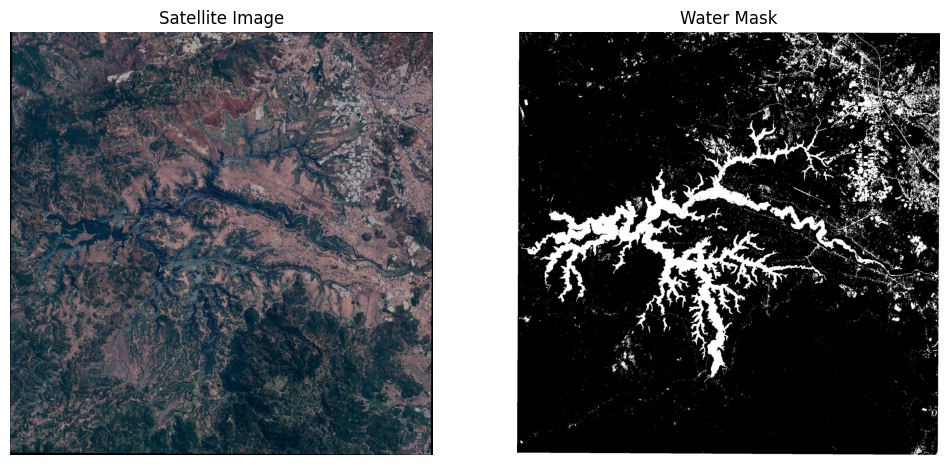

In [7]:
image_dir = dataset_path + "/Water Bodies Dataset/Images"
mask_dir = dataset_path + "/Water Bodies Dataset/Masks"

image_files = sorted(os.listdir(image_dir))

sample_file = image_files[0]

print("Sample file:", sample_file)

img_path = os.path.join(image_dir, sample_file)
mask_path = os.path.join(mask_dir, sample_file)

img = Image.open(img_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Water Mask")
plt.axis("off")

plt.show()

In [8]:
pairs = []

for file_name in os.listdir(image_dir):

    image_path = os.path.join(image_dir, file_name)
    mask_path = os.path.join(mask_dir, file_name)

    if os.path.exists(mask_path):

        pairs.append((image_path, mask_path))

print("Total pairs:", len(pairs))

print("\nSample pair:")
print(pairs[0])

Total pairs: 2841

Sample pair:
('/content/gdrive/MyDrive/water_dataset/Water Bodies Dataset/Images/water_body_1219.jpg', '/content/gdrive/MyDrive/water_dataset/Water Bodies Dataset/Masks/water_body_1219.jpg')


In [9]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

Train pairs: 2272
Validation pairs: 569


In [10]:
processor = SegformerImageProcessor(
    do_reduce_labels=False
)

In [11]:
class WaterDataset(Dataset):

    def __init__(self, pairs, processor):

        self.pairs = pairs
        self.processor = processor

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_path, mask_path = self.pairs[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = np.array(image)
        mask = np.array(mask)

        # Binary mask
        mask = (mask > 0).astype(np.uint8)

        encoding = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        pixel_values = encoding["pixel_values"].squeeze()
        labels = encoding["labels"].squeeze()

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

In [12]:
train_dataset = WaterDataset(train_pairs, processor)
val_dataset = WaterDataset(val_pairs, processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2
)

print("Water datasets ready.")

Water datasets ready.


In [13]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    ignore_mismatched_sizes=True
)

print("Water model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Water model loaded.


In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print(device)

cuda


In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5
)

In [16]:
from tqdm import tqdm

model.train()

EPOCHS = 5

for epoch in range(EPOCHS):

    total_loss = 0

    loop = tqdm(train_loader)

    for batch in loop:

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")

        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 1136/1136 [03:05<00:00,  6.13it/s, loss=0.587]



Epoch 1 Average Loss: 0.3973


Epoch 2: 100%|██████████| 1136/1136 [03:01<00:00,  6.27it/s, loss=0.293]



Epoch 2 Average Loss: 0.3355


Epoch 3: 100%|██████████| 1136/1136 [03:00<00:00,  6.31it/s, loss=0.309]



Epoch 3 Average Loss: 0.3086


Epoch 4: 100%|██████████| 1136/1136 [02:59<00:00,  6.32it/s, loss=0.214]



Epoch 4 Average Loss: 0.2923


Epoch 5: 100%|██████████| 1136/1136 [02:58<00:00,  6.36it/s, loss=0.215]


Epoch 5 Average Loss: 0.2797


In [17]:
test_image_path = val_pairs[0][0]

print(test_image_path)

/content/gdrive/MyDrive/water_dataset/Water Bodies Dataset/Images/water_body_7791.jpg


In [18]:
model.eval()

image = Image.open(test_image_path).convert("RGB")

image_np = np.array(image)

inputs = processor(
    images=image_np,
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

with torch.no_grad():

    outputs = model(pixel_values=pixel_values)

logits = outputs.logits

pred_mask = torch.argmax(
    logits,
    dim=1
).squeeze().cpu().numpy()

In [19]:
pred_mask = cv2.resize(
    pred_mask.astype(np.uint8),
    (image_np.shape[1], image_np.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

In [20]:
overlay = image_np.copy()

# Water = blue
overlay[pred_mask == 1] = [0, 0, 255]

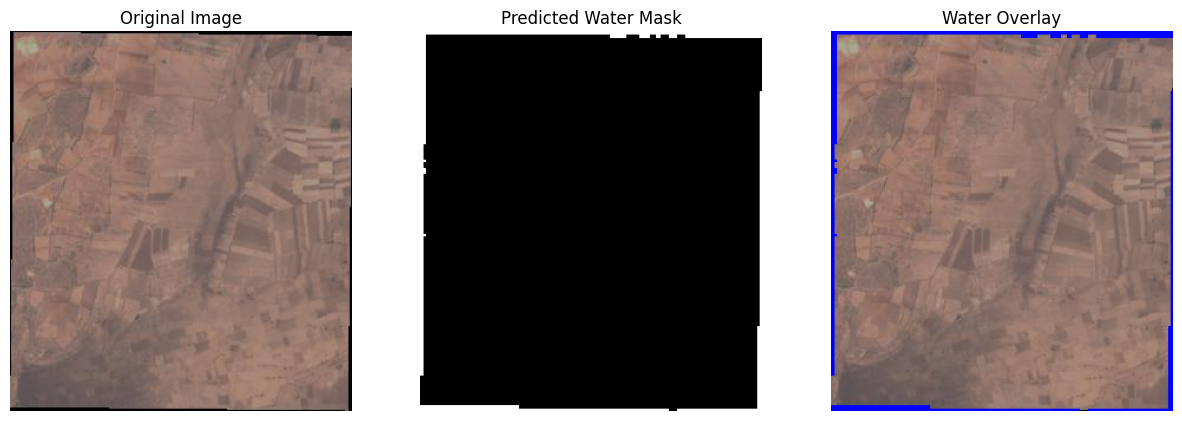

In [21]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Water Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Water Overlay")
plt.axis("off")

plt.show()

In [22]:
water_pixels = np.sum(pred_mask == 1)

total_pixels = pred_mask.size

water_percent = (water_pixels / total_pixels) * 100

print("Water Coverage:", round(water_percent, 2), "%")

Water Coverage: 4.0 %


In [23]:
alerts = []

if water_percent > 25:
    alerts.append(
        "Large water body presence detected."
    )

if water_percent > 40:
    alerts.append(
        "Potential flood-prone region identified."
    )

print("Alerts:\n")

for alert in alerts:
    print("-", alert)

Alerts:



In [24]:
from PIL import Image

overlay_image = Image.fromarray(overlay)

overlay_image.save("water_overlay_result.png")

print("Overlay image saved.")

Overlay image saved.


In [25]:
torch.save(
    model.state_dict(),
    "water_segformer.pth"
)

print("Water model saved.")

Water model saved.


In [26]:
torch.save(
    model.state_dict(),
    "/content/gdrive/MyDrive/water_segformer.pth"
)

print("Model backed up to Drive.")

Model backed up to Drive.


In [27]:
from google.colab import files

files.download("water_segformer.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
files.download("water_overlay_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>